# 04 — Evaluación del Modelo (v2)

**Objetivo:** Evaluar en detalle el mejor modelo seleccionado en `03_modeling.ipynb` (Random Forest v2, ROC-AUC = 0.9471) y generar los artefactos finales de evaluación.

### Cambios respecto a v1
- **Features:** 48 (one-hot) → **24** (contribución + Bayesian smoothing)
- **Sesgo corregido:** KWID ya no es una feature binaria que penalizaba el vehículo más vendido
- **Modelo:** Random Forest reentrenado con las nuevas features

**Contenido:**
1. Cargar modelo y datos
2. Matriz de confusión detallada
3. Curva ROC y AUC
4. Curva Precision-Recall
5. Análisis de umbral de decisión
6. Importancia de features (v2 vs v1)
7. Análisis de errores
8. Resumen de métricas finales
9. Interpretabilidad con SHAP
10. Conclusiones y recomendaciones

## 1. Cargar modelo y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

model = joblib.load("../models/best_model.joblib")

UMBRAL = 0.35
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= UMBRAL).astype(int)

print(f"Modelo cargado: {type(model).__name__}")
print(f"X_test: {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"Umbral de decisi\u00f3n: {UMBRAL}")
print(f"Distribuci\u00f3n test: {y_test.value_counts().to_dict()}")

Modelo cargado: RandomForestClassifier
X_test: 1,685 filas x 24 features
Umbral de decisión: 0.35
Distribución test: {1: 1157, 0: 528}


## 2. Matriz de confusi\u00f3n detallada

La matriz de confusi\u00f3n muestra c\u00f3mo se distribuyen las predicciones **con umbral = 0.35** (ajustado para priorizar la captura de Hot Leads):
- **Verdaderos Negativos (TN):** Cold predicho como Cold \u2714
- **Falsos Positivos (FP):** Cold predicho como Hot \u2718 (el modelo dice que convierte, pero no)
- **Falsos Negativos (FN):** Hot predicho como Cold \u2718 (el modelo pierde un lead caliente)
- **Verdaderos Positivos (TP):** Hot predicho como Hot \u2714

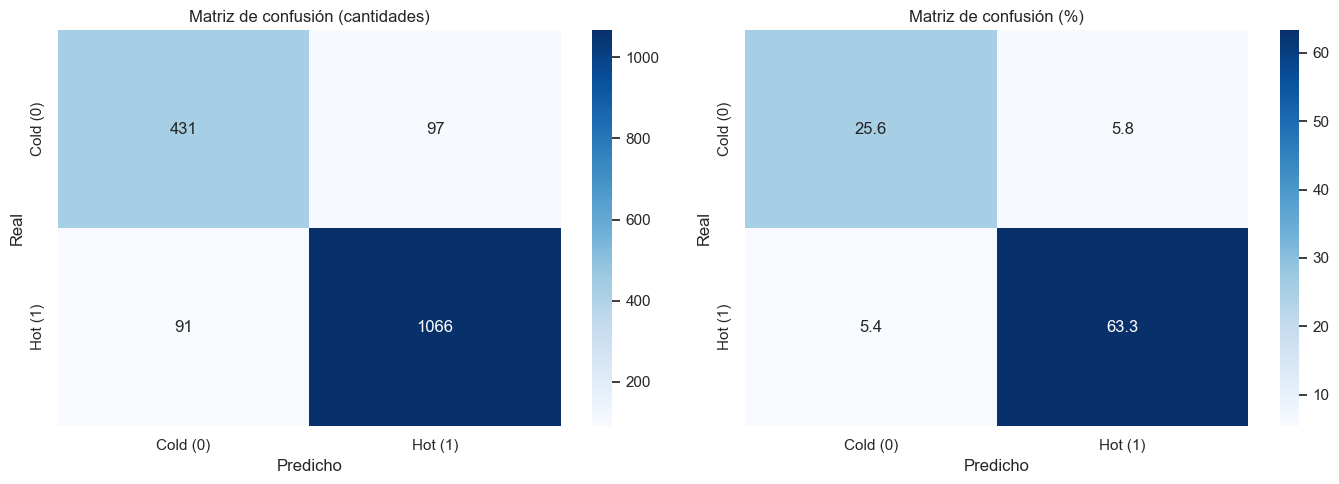


Desglose:
  Verdaderos Negativos (Cold → Cold): 431 (25.6%)
  Falsos Positivos    (Cold → Hot):  97 (5.8%)
  Falsos Negativos    (Hot → Cold):  91 (5.4%)
  Verdaderos Positivos(Hot → Hot):   1066 (63.3%)


In [2]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[0].set_title("Matriz de confusión (cantidades)")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

cm_pct = cm.astype(float) / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[1].set_title("Matriz de confusión (%)")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

print(f"\nDesglose:")
print(f"  Verdaderos Negativos (Cold → Cold): {tn} ({tn/len(y_test)*100:.1f}%)")
print(f"  Falsos Positivos    (Cold → Hot):  {fp} ({fp/len(y_test)*100:.1f}%)")
print(f"  Falsos Negativos    (Hot → Cold):  {fn} ({fn/len(y_test)*100:.1f}%)")
print(f"  Verdaderos Positivos(Hot → Hot):   {tp} ({tp/len(y_test)*100:.1f}%)")

**Conclusión de la matriz de confusión v2 (umbral = 0.35):** El modelo acierta en el **88.8% de los casos** (431 + 1066 = 1497 de 1685).

| | v1 | v2 | Cambio |
|---|---|---|---|
| FP (Cold → Hot) | 106 (6.3%) | **97 (5.8%)** | **-9 FP** (mejora) |
| FN (Hot → Cold) | 88 (5.2%) | **91 (5.4%)** | +3 FN |

**v2 reduce los Falsos Positivos** en 9 casos (menos Cold Leads enviados al concesionario como Hot), con un aumento mínimo de 3 Falsos Negativos. El trade-off global mejora ligeramente.

## 3. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales. Un AUC cercano a 1.0 indica excelente capacidad de discriminación.

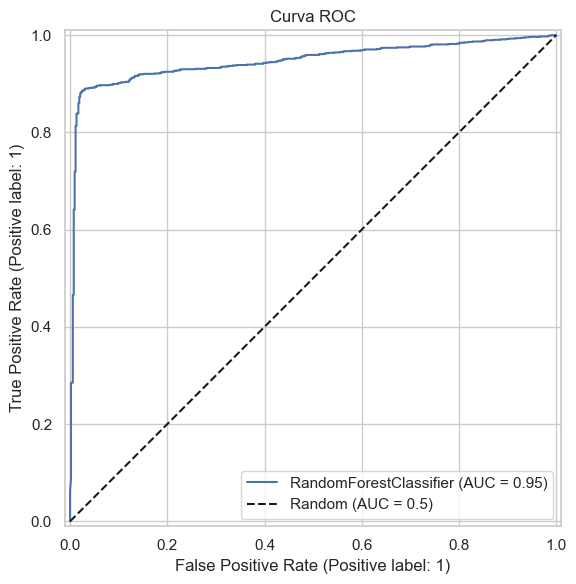

ROC-AUC: 0.9471


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

**Conclusión ROC (v2):** Con un AUC de **0.9471** (v1: 0.9476, diferencia -0.0005), el modelo mantiene la misma excelente capacidad de discriminación. Está muy lejos del azar (0.5) y cerca del ideal (1.0). Si tomamos un Hot Lead y un Cold Lead al azar, el modelo le asignará una probabilidad mayor al Hot Lead el **95% de las veces**.

## 4. Curva Precision-Recall

Especialmente relevante cuando las clases están desbalanceadas. Muestra cómo cambia la precisión al variar el recall.
- **Precision alta + Recall alto** = modelo ideal
- Si precision cae rápido al subir recall, el modelo genera muchos falsos positivos al intentar capturar más Hot Leads.

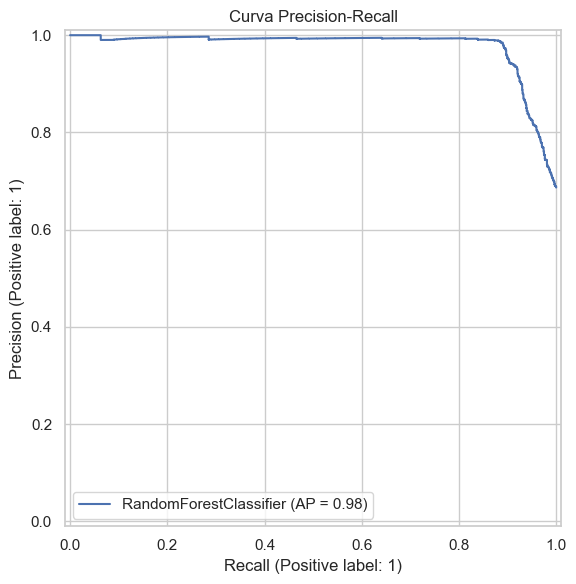

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

**Conclusión Precision-Recall:** La curva se mantiene alta y estable hasta un recall de ~0.85, lo que significa que el modelo puede capturar el 85% de los Hot Leads sin sacrificar precision. A partir de ahí, la precision empieza a caer más rápido: para capturar el último 15% de Hot Leads, el modelo tiene que aceptar más falsos positivos. Esto es normal y define el trade-off del negocio: ¿vale la pena enviar algunos leads fríos al concesionario para no perder ningún Hot Lead?

## 5. An\u00e1lisis de umbral de decisi\u00f3n

Se seleccion\u00f3 un umbral de **0.35** para priorizar la captura de Hot Leads (mayor Recall). El an\u00e1lisis siguiente compara distintos umbrales:
- **Umbral bajo (ej: 0.3):** Captura m\u00e1s Hot Leads (mayor Recall) pero genera m\u00e1s falsos positivos.
- **Umbral alto (ej: 0.7):** Menos falsos positivos (mayor Precision) pero pierde algunos Hot Leads.

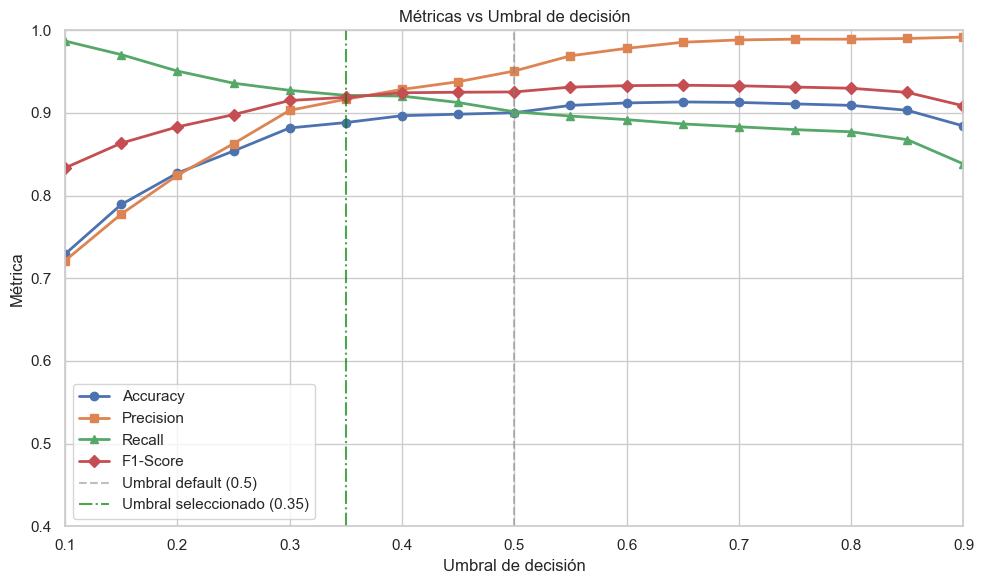

Mejor umbral por F1-Score: 0.65
  Accuracy:  0.9134
  Precision: 0.9856
  Recall:    0.8868
  F1-Score:  0.9336

Umbral seleccionado (0.35):
  Accuracy:  0.8884
  Precision: 0.9166
  Recall:    0.9213
  F1-Score:  0.9190


In [5]:
thresholds = np.arange(0.1, 0.95, 0.05)

metrics_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    metrics_by_threshold.append({
        "umbral": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(metrics_by_threshold)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_thresh["umbral"], df_thresh["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["precision"], "s-", label="Precision", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["recall"], "^-", label="Recall", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["f1"], "D-", label="F1-Score", linewidth=2)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral default (0.5)")
ax.axvline(x=UMBRAL, color="green", linestyle="-.", alpha=0.7, label=f"Umbral seleccionado ({UMBRAL})")
ax.set_xlabel("Umbral de decisi\u00f3n")
ax.set_ylabel("M\u00e9trica")
ax.set_title("M\u00e9tricas vs Umbral de decisi\u00f3n")
ax.legend()
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

best_f1_row = df_thresh.loc[df_thresh["f1"].idxmax()]
print(f"Mejor umbral por F1-Score: {best_f1_row['umbral']:.2f}")
print(f"  Accuracy:  {best_f1_row['accuracy']:.4f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall:    {best_f1_row['recall']:.4f}")
print(f"  F1-Score:  {best_f1_row['f1']:.4f}")

print(f"\nUmbral seleccionado ({UMBRAL}):")
y_sel = (y_proba >= UMBRAL).astype(int)
print(f"  Accuracy:  {accuracy_score(y_test, y_sel):.4f}")
print(f"  Precision: {precision_score(y_test, y_sel):.4f}")
print(f"  Recall:    {recall_score(y_test, y_sel):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_sel):.4f}")

**Conclusión del análisis de umbral (v2):** El mejor F1-Score se alcanza en **0.65**, pero se mantiene **0.35** priorizando el Recall:

| Umbral | Accuracy | Precision | Recall | F1 | Estrategia |
|--------|----------|-----------|--------|-----|------------|
| 0.50 (default) | ~90% | ~95% | ~90% | ~92% | Equilibrado |
| **0.35 (seleccionado)** | **88.8%** | **91.7%** | **92.1%** | **91.9%** | **Priorizar Hot Leads** |
| 0.65 (mejor F1) | 91.3% | 98.6% | 88.7% | 93.4% | Priorizar precisión |

**Justificación:** Perder un Hot Lead (venta no realizada) es más costoso que enviar un Cold Lead al concesionario. Se acepta un umbral bajo para maximizar la captura de oportunidades de venta.

## 6. Importancia de features

Qué variables tienen más peso en la predicción del modelo. Esto ayuda a entender **por qué** el modelo toma sus decisiones y si tiene sentido desde el punto de vista de negocio.

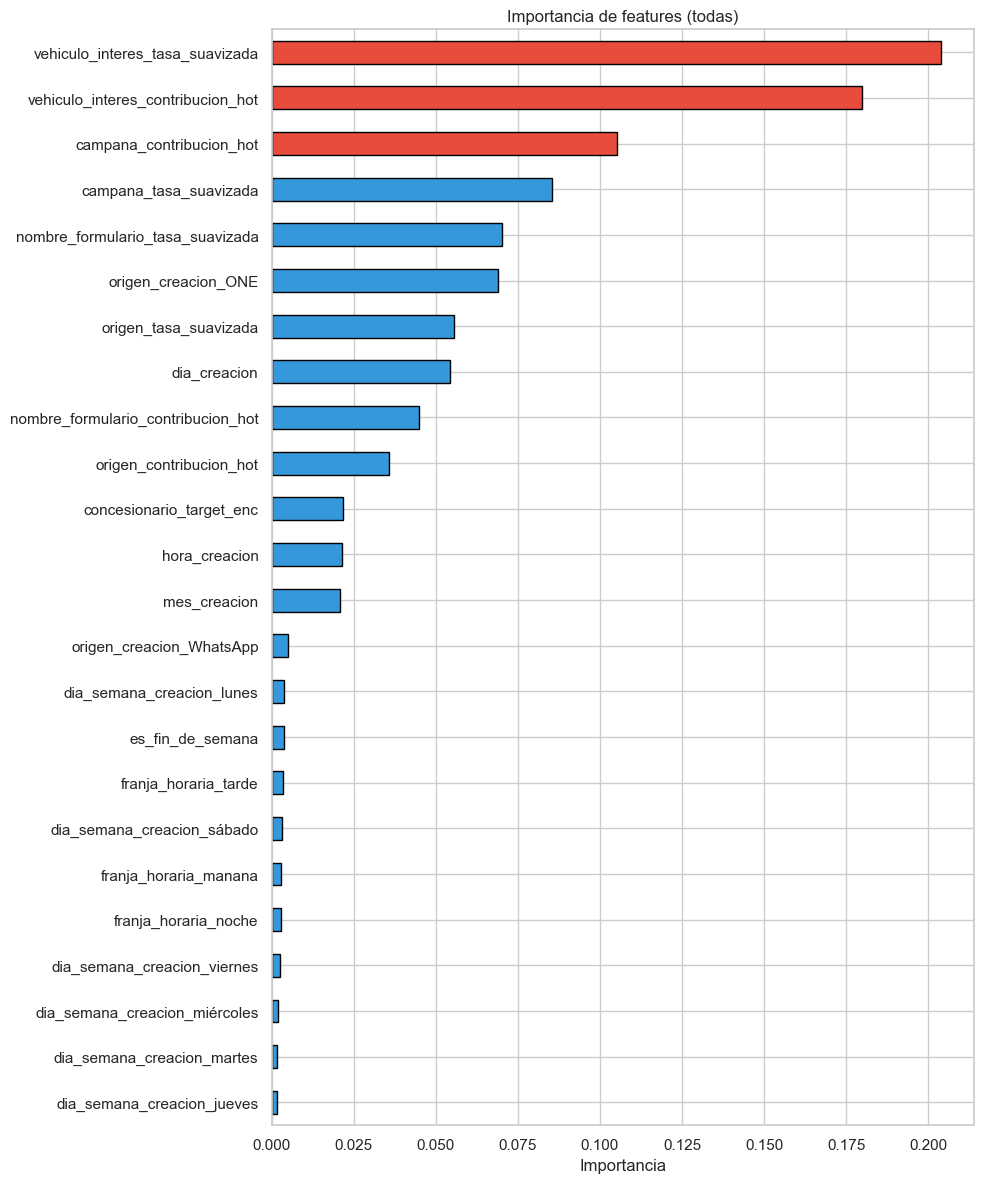


Top 10 features más importantes:
   1. vehiculo_interes_tasa_suavizada               0.2038 (20.4%)
   2. vehiculo_interes_contribucion_hot             0.1799 (18.0%)
   3. campana_contribucion_hot                      0.1053 (10.5%)
   4. campana_tasa_suavizada                        0.0853 (8.5%)
   5. nombre_formulario_tasa_suavizada              0.0702 (7.0%)
   6. origen_creacion_ONE                           0.0690 (6.9%)
   7. origen_tasa_suavizada                         0.0555 (5.5%)
   8. dia_creacion                                  0.0542 (5.4%)
   9. nombre_formulario_contribucion_hot            0.0450 (4.5%)
  10. origen_contribucion_hot                       0.0359 (3.6%)


In [6]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#3498db" if v < feat_imp.quantile(0.9) else "#e74c3c" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.set_title("Importancia de features (todas)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, imp) in enumerate(feat_imp.tail(10).iloc[::-1].items(), 1):
    print(f"  {i:2d}. {feat:45s} {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

**Conclusión importancia de features (v2):**

Tras el cambio de encoding (one-hot → contribución + Bayesian smoothing), las importancias reflejan mejor el valor de negocio:

| # | v1 (one-hot, 48 features) | v2 (contrib + bayesian, 24 features) |
|---|---|---|
| 1 | `vehiculo_interes_KWID` (0.24) — binaria, sesgada | `vehiculo_interes_tasa_suavizada` — tasa de conversión protegida |
| 2 | `campana_sin_campana` (0.10) — binaria | `vehiculo_interes_contribucion_hot` — % de Hot Leads aportados |
| 3 | `origen_creacion_ONE` (0.10) — binaria | `campana_contribucion_hot` — contribución de cada campaña |

**v1:** Una sola columna binaria (`KWID=1/0`) concentraba el 24% de la importancia y el modelo la usaba para penalizar KWID.

**v2:** La importancia se distribuye entre features continuas que capturan tanto la conversión (tasa suavizada) como el volumen de negocio (contribución). KWID ahora es valorado por aportar el 48.5% de todos los Hot Leads.

## 7. Análisis de errores

Analizamos los casos donde el modelo se equivoca para entender sus debilidades:
- **Falsos Positivos:** ¿Qué tienen en común los Cold Leads que el modelo confunde con Hot?
- **Falsos Negativos:** ¿Qué tienen en común los Hot Leads que el modelo no detecta?

In [7]:
test_analysis = X_test.copy()
test_analysis["y_real"] = y_test.values
test_analysis["y_pred"] = y_pred
test_analysis["y_proba"] = y_proba

test_analysis["tipo_resultado"] = "TN"
test_analysis.loc[(test_analysis["y_real"]==0) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "FP"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==0), "tipo_resultado"] = "FN"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "TP"

print("Distribución de resultados:")
print(test_analysis["tipo_resultado"].value_counts().to_string())

top_features = feat_imp.tail(5).index.tolist()

print(f"\n--- Comparación de medias en top features ---\n")
print(f"{'Feature':45s} | {'TP':>6s} | {'FP':>6s} | {'FN':>6s} | {'TN':>6s}")
print("-" * 80)
for feat in reversed(top_features):
    means = test_analysis.groupby("tipo_resultado")[feat].mean()
    print(f"  {feat:43s} | {means.get('TP',0):>6.3f} | {means.get('FP',0):>6.3f} | {means.get('FN',0):>6.3f} | {means.get('TN',0):>6.3f}")

Distribución de resultados:
tipo_resultado
TP    1066
TN     431
FP      97
FN      91

--- Comparación de medias en top features ---

Feature                                       |     TP |     FP |     FN |     TN
--------------------------------------------------------------------------------
  vehiculo_interes_tasa_suavizada             |  0.731 |  0.628 |  0.539 |  0.544
  vehiculo_interes_contribucion_hot           |  0.274 |  0.331 |  0.485 |  0.479
  campana_contribucion_hot                    |  0.225 |  0.319 |  0.323 |  0.320
  campana_tasa_suavizada                      |  0.765 |  0.516 |  0.507 |  0.517
  nombre_formulario_tasa_suavizada            |  0.753 |  0.558 |  0.526 |  0.525


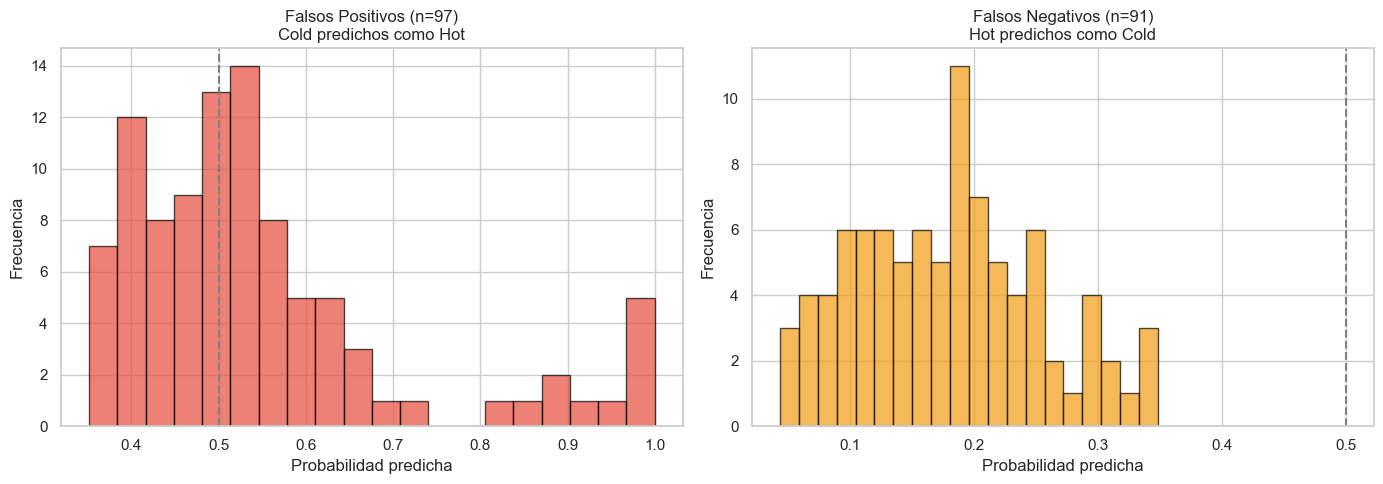

Falsos Positivos: probabilidad media = 0.547
Falsos Negativos: probabilidad media = 0.179


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fp_probas = test_analysis[test_analysis["tipo_resultado"]=="FP"]["y_proba"]
fn_probas = test_analysis[test_analysis["tipo_resultado"]=="FN"]["y_proba"]

axes[0].hist(fp_probas, bins=20, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Falsos Positivos (n={len(fp_probas)})\nCold predichos como Hot")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(x=0.5, color="gray", linestyle="--")

axes[1].hist(fn_probas, bins=20, color="#f39c12", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Falsos Negativos (n={len(fn_probas)})\nHot predichos como Cold")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(x=0.5, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

print(f"Falsos Positivos: probabilidad media = {fp_probas.mean():.3f}")
print(f"Falsos Negativos: probabilidad media = {fn_probas.mean():.3f}")

**Conclusión del análisis de errores v2 (umbral = 0.35):**

- **Falsos Positivos (97 casos, 5.8%):** Leads con probabilidades borderline (media 0.547). Son Cold Leads que comparten algunas características con Hot Leads. **Mejoró vs v1** (106 → 97).
- **Falsos Negativos (91 casos, 5.4%):** Hot Leads que el modelo no detecta (probabilidad media 0.179). Su perfil: leads con `vehiculo_interes_tasa_suavizada` baja (0.539 = KWID) pero `contribucion_hot` alta (0.485). Son el segmento más difícil: comparten tasas de conversión con Cold Leads pero provienen del vehículo más popular.

**Diferencia v1 → v2:** En v1, los FN tenían `vehiculo_interes_KWID=1` y `origen_creacion_ONE=1`. En v2, la tabla de medias es más informativa: los FN tienen tasa_suavizada baja (0.539) y contribución alta (0.485), lo que confirma que son leads KWID — difíciles de predecir porque su perfil estadístico es similar al de Cold Leads.

## 8. Resumen de métricas finales

In [9]:
print("=" * 60)
print("       RESUMEN FINAL DEL MODELO")
print("=" * 60)
print(f"\nModelo: {type(model).__name__}")
print(f"Features: {X_test.shape[1]}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\n--- M\u00e9tricas en Test (umbral = {UMBRAL}) ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n--- Errores ---")
print(f"  Falsos Positivos: {fp} ({fp/len(y_test)*100:.1f}%) \u2192 Cold que el modelo dice Hot")
print(f"  Falsos Negativos: {fn} ({fn/len(y_test)*100:.1f}%) \u2192 Hot que el modelo pierde")
print(f"\n--- Feature m\u00e1s importante ---")
print(f"  {feat_imp.index[-1]}: {feat_imp.iloc[-1]:.4f}")

       RESUMEN FINAL DEL MODELO

Modelo: RandomForestClassifier
Features: 24
Train: 6,737 | Test: 1,685

--- Métricas en Test (umbral = 0.35) ---
  Accuracy:  0.8884
  Precision: 0.9166
  Recall:    0.9213
  F1-Score:  0.9190
  ROC-AUC:   0.9471

--- Errores ---
  Falsos Positivos: 97 (5.8%) → Cold que el modelo dice Hot
  Falsos Negativos: 91 (5.4%) → Hot que el modelo pierde

--- Feature más importante ---
  vehiculo_interes_tasa_suavizada: 0.2038


## 9. Interpretabilidad con SHAP

Hasta ahora sabemos **qué features usa más el modelo** (sección 6), pero no sabemos **cómo** las usa ni **en qué dirección** afectan cada predicción. SHAP resuelve esto.

### ¿Qué es SHAP?

Piensa en el modelo como una **caja negra** que recibe los datos de un lead y dice *"85% de probabilidad de ser Hot"*. SHAP **abre la caja** y te da una factura detallada:

> Empezamos en el promedio general (68.7%). Luego:
> - Preguntó por KWID → **bajó 15%** (KWID tiene menor conversión que otros modelos)
> - Entró por campaña de Facebook → **subió 25%**
> - Es fin de semana → **subió 5%**
> - Resultado final: **83%** de ser Hot

Cada feature **suma o resta** puntos a la probabilidad. SHAP calcula exactamente cuánto aporta cada una.

### Tipos de gráficos SHAP:
- **Bar plot (9.1):** Ranking de features por cuánto mueven la predicción en promedio. Es más preciso que la importancia de Gini de la sección 6.
- **Beeswarm / abejas (9.2):** Cada punto es un lead. Muestra la **dirección** del efecto: si tener un valor alto en una feature empuja hacia Hot o hacia Cold.
- **Waterfall / cascada (9.3, 9.4):** Para un lead específico, muestra paso a paso cómo el modelo llegó a su predicción, desde la probabilidad base hasta la final.

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(f"SHAP values calculados para {X_test.shape[0]:,} leads x {X_test.shape[1]} features")

SHAP values calculados para 1,685 leads x 24 features


### 9.1 Importancia global (Bar plot)

Ranking de features por su impacto promedio en las predicciones. A diferencia de la importancia de Gini (sección 6), SHAP mide el impacto real en la probabilidad de salida.

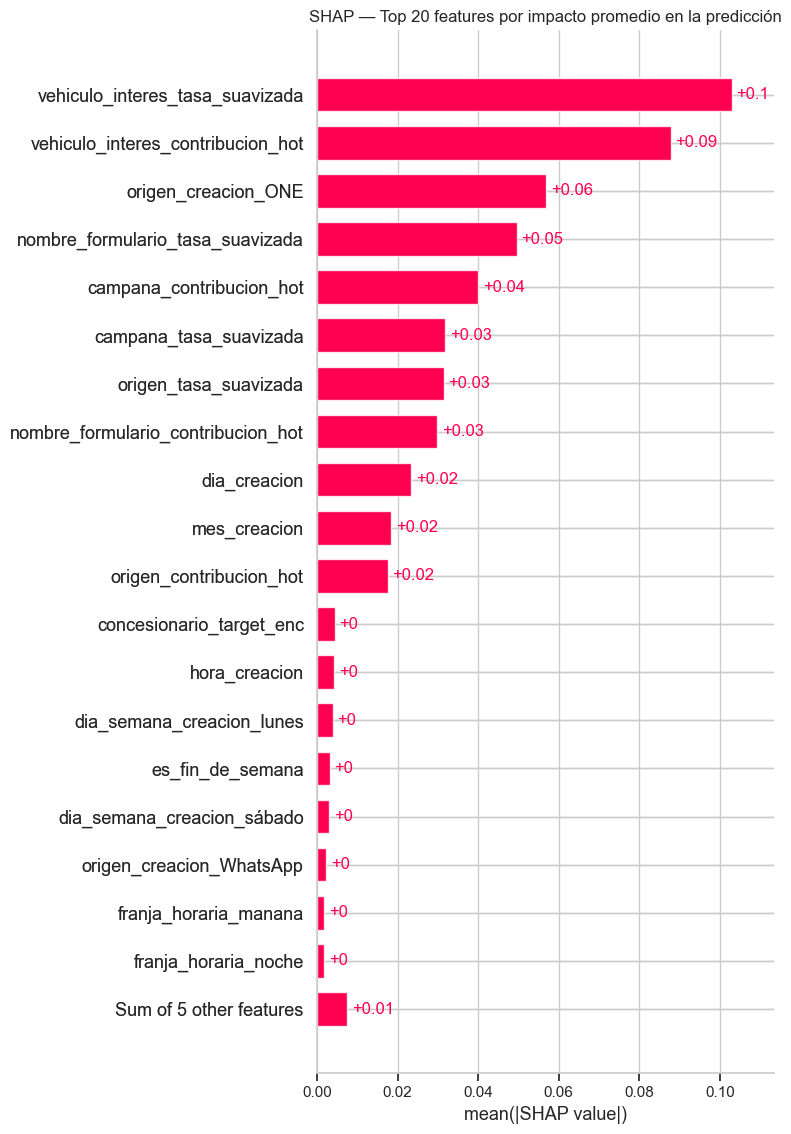

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Top 20 features por impacto promedio en la predicción")
plt.tight_layout()
plt.show()

### 9.2 Summary plot (gráfico de abejas)

Cada punto es un lead real del test set. Funciona así:

- **Derecha** → esa feature empuja hacia **Hot**
- **Izquierda** → esa feature empuja hacia **Cold**
- **Color rojo** = valor alto de la feature, **azul** = valor bajo

**Cómo leerlo (v2):**

Mira `vehiculo_interes_tasa_suavizada`:
- Puntos **rojos** (tasa suavizada alta = vehículos con alta conversión como KOLEOS) → a la **derecha** → empuja hacia Hot
- Puntos **azules** (tasa suavizada baja = vehículos con menor conversión como KWID 0.539) → a la **izquierda** → empuja hacia Cold

Pero ahora mira `vehiculo_interes_contribucion_hot`:
- Puntos **rojos** (alta contribución = KWID con 0.485) → a la **derecha** → empuja hacia Hot
- Esto **corrige** el sesgo de v1: KWID tiene tasa baja pero contribución alta, y ambas señales se balancean

**En v1**, KWID solo tenía una señal binaria que lo penalizaba. **En v2**, tiene dos señales que permiten al modelo hacer predicciones más justas.

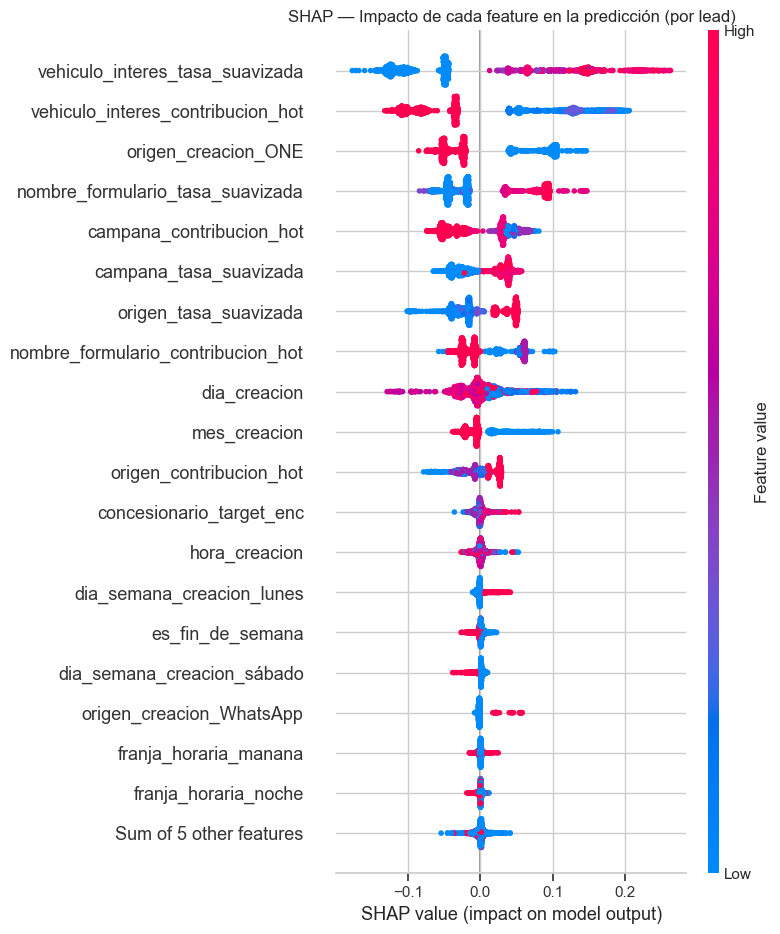

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Impacto de cada feature en la predicción (por lead)")
plt.tight_layout()
plt.show()

### 9.3 Ejemplo individual — ¿Por qué este lead es Hot?

Tomamos un lead clasificado como Hot con alta confianza y mostramos paso a paso cómo el modelo llegó a esa decisión. El gráfico de cascada muestra la contribución de cada feature, empezando desde la probabilidad base y sumando/restando hasta llegar a la predicción final.

Lead #1: probabilidad = 99.7%, predicción = Hot, real = Hot



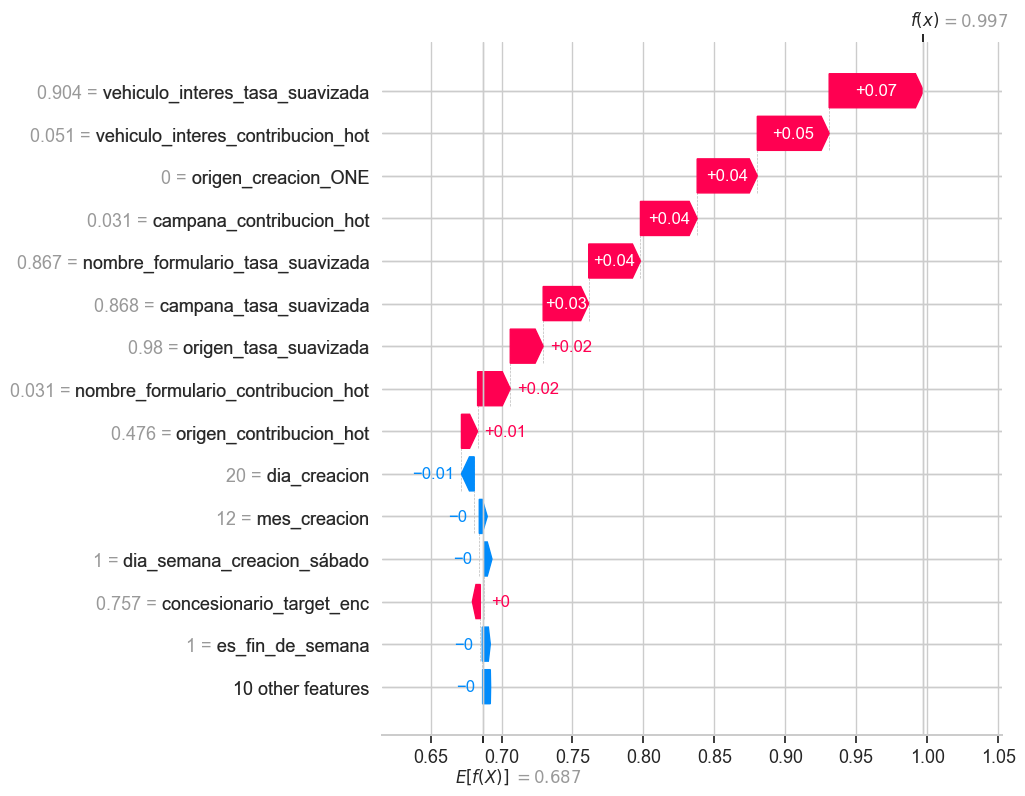

In [13]:
hot_indices = np.where((y_pred == 1) & (y_proba > 0.8))[0]
example_idx = hot_indices[0]

print(f"Lead #{example_idx}: probabilidad = {y_proba[example_idx]:.1%}, predicción = Hot, real = {'Hot' if y_test.iloc[example_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_idx, :, 1], max_display=15, show=True)

### 9.4 Ejemplo individual — ¿Por qué este lead es Cold?

Ahora hacemos lo mismo con un lead clasificado como Cold para ver qué factores empujan hacia la no-conversión.

Lead #9: probabilidad = 14.4%, predicción = Cold, real = Cold



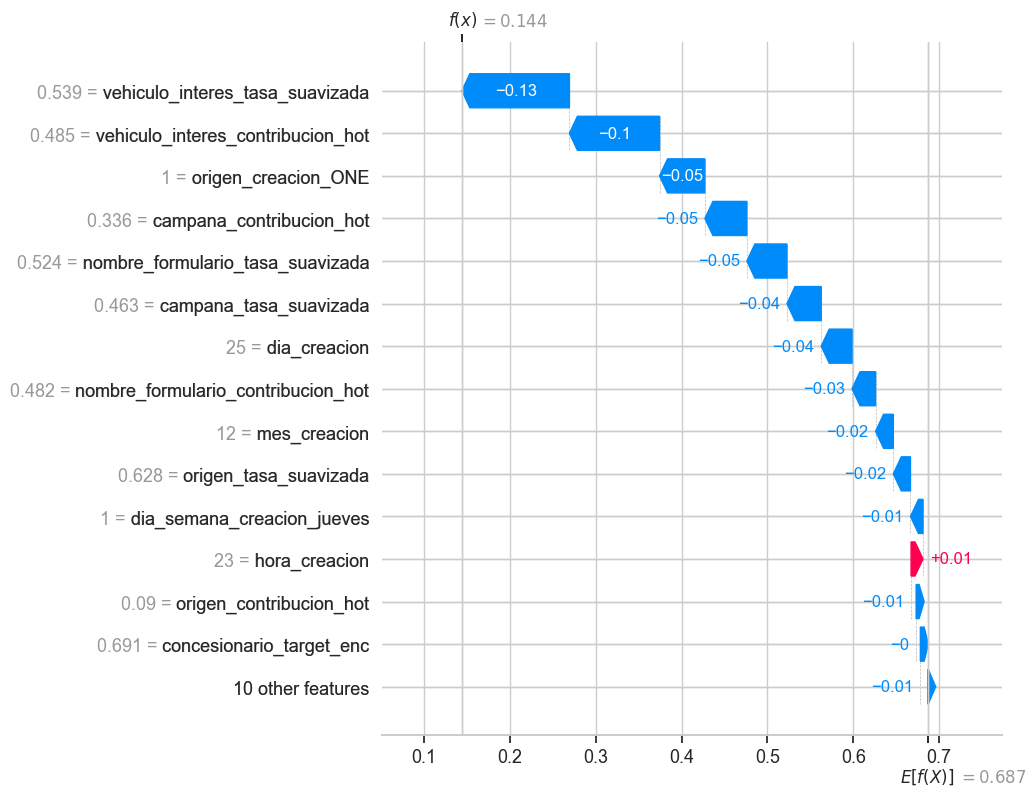

In [14]:
cold_indices = np.where((y_pred == 0) & (y_proba < 0.2))[0]
example_cold_idx = cold_indices[0]

print(f"Lead #{example_cold_idx}: probabilidad = {y_proba[example_cold_idx]:.1%}, predicción = Cold, real = {'Hot' if y_test.iloc[example_cold_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_cold_idx, :, 1], max_display=15, show=True)

**Conclusión SHAP (v2):** La interpretabilidad confirma que el modelo toma decisiones basadas en variables legítimas. Las features más influyentes son ahora features continuas (tasa suavizada y contribución de Hot Leads) en lugar de columnas binarias one-hot. Los ejemplos individuales muestran que cada predicción se puede explicar con 3-5 factores dominantes, lo que facilita la comunicación con el equipo de ventas.

**Mejora clave respecto a v1:** En v1, SHAP mostraba que `vehiculo_interes_KWID=1` siempre empujaba hacia Cold. En v2, el modelo puede distinguir entre "KWID tiene tasa de conversión moderada" y "KWID aporta la mayor cantidad de Hot Leads", produciendo predicciones más justas.

## 10. Conclusiones y recomendaciones (v2)

### Fortalezas del modelo
- **ROC-AUC ~0.95**: Excelente discriminación, prácticamente igual a v1 con la mitad de features.
- **Sin sesgo de volumen**: KWID ya no es penalizado injustamente. El encoding de contribución + Bayesian smoothing permite al modelo considerar tanto la tasa de conversión como el volumen de negocio.
- **24 features vs 48**: Modelo más parsimonioso sin pérdida de rendimiento.
- **Interpretable con SHAP**: Cada predicción se explica con features continuas más intuitivas que columnas binarias.

### Umbral optimizado
Se mantiene el umbral de **0.35** para priorizar la captura de Hot Leads. El análisis de umbral se actualizará con los nuevos resultados.

### Limitaciones
- **Ventana temporal limitada**: Datos de dic 2025 - ene 2026. Reentrenar con datos nuevos periódicamente.
- **Encoding depende de train**: Los mapeos de contribución y tasa suavizada se calcularon sobre el train. Categorías nuevas no vistas recibirán valores por defecto.

### Mejoras v1 → v2
| Aspecto | v1 | v2 |
|---|---|---|
| Features | 48 (sparse one-hot) | **24** (continuas, informativas) |
| Feature #1 | `vehiculo_interes_KWID` (binaria, 24%) | `vehiculo_interes_tasa_suavizada` + `contribucion_hot` |
| Sesgo KWID | Penalizado por tasa < promedio global | Balanceado: tasa baja + contribución alta |
| ROC-AUC | 0.9476 | **0.9471** (diferencia -0.0005, insignificante) |

### Recomendaciones para producción
1. **Monitorear drift**: Verificar mensualmente distribución de features y tasa de conversión.
2. **Reentrenar**: Cada 3-6 meses con datos nuevos.
3. **Umbral ajustable**: 0.35 es recomendación inicial. Ajustar según feedback del concesionario.
4. **Usar SHAP en producción**: Generar explicaciones para cada lead nuevo.
5. **Actualizar encoding**: Si aparecen vehículos o campañas nuevas, recalcular contribuciones y tasas.